# L-Maze: Comparison

## Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [1]:
import numpy as np
np.set_printoptions(precision=2)

In [2]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

## Define A L-Maze Grid World 

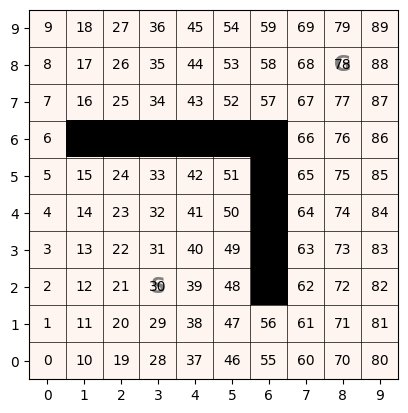

In [3]:
gym_env = gym.make('LMaze-v0')
env = gym_env.unwrapped

env.image()

In [4]:
# For comparison
cum_average_returns = {}

In [5]:
from gym_classics.performance import plot_returns, plot_ep_lens

## Monte Carlo Methods

MC Control (Incremental): 100%|██████████| 2000/2000 [00:06<00:00, 306.54it/s]


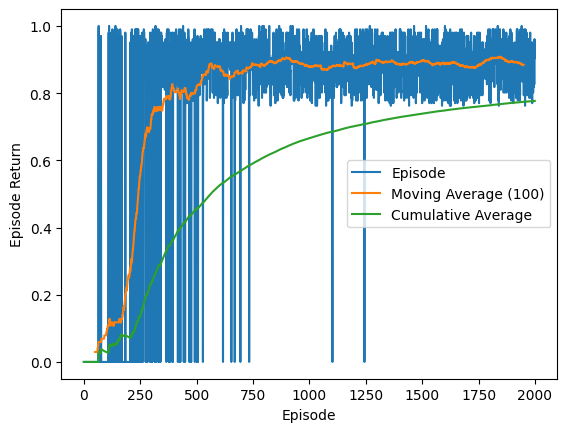

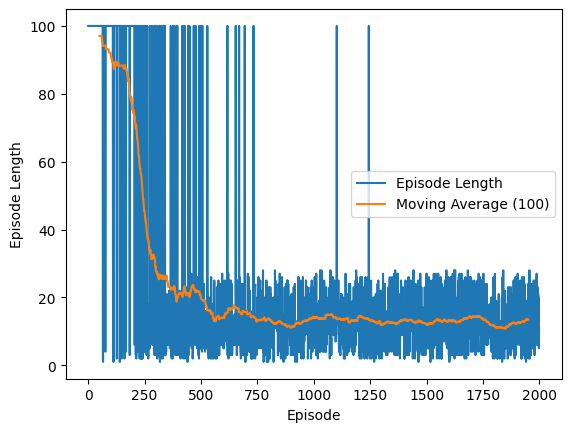

In [7]:
from gym_classics.algorithms.monte_carlo_methods import MC_control_ES

policy, Q, history = MC_control_ES(env, n=2000, discount=.99, history = True)

plot_returns(history["returns"])
plot_ep_lens([len(x) for x in history["episodes"]])

# We cannot use the results from exploring starts because episodes do not start from the start state
cum_average_returns["MC Control ES"] = np.nan 

## Tabular Temporal Differencing Methods

Sarsa: 100%|██████████| 2000/2000 [00:05<00:00, 384.14it/s]


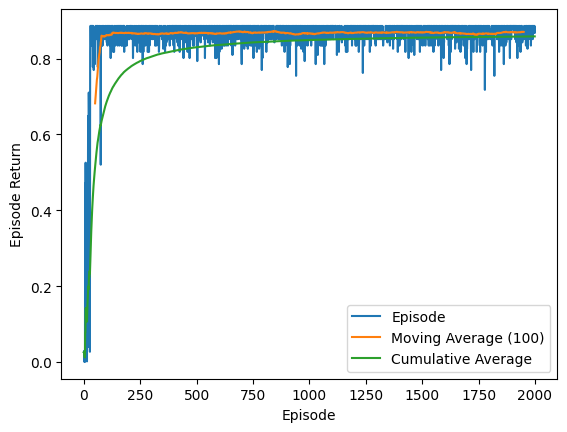

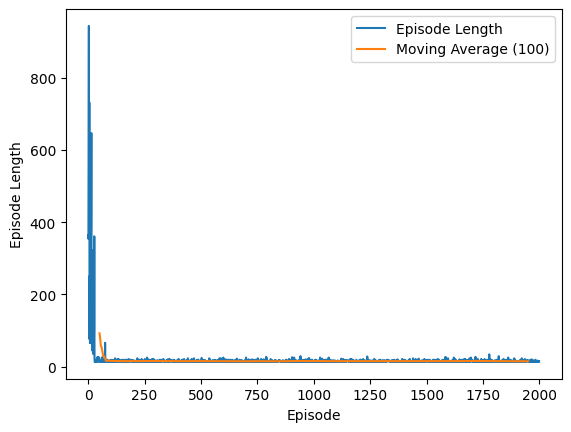

In [8]:
from gym_classics.algorithms.temporal_difference_learning import Sarsa

Q, history = Sarsa(env, n=2000, discount=.99, alpha = 0.01, epsilon = 0.1, history = True)

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

cum_average_returns["Sarsa"] = np.sum(history["returns"])/len(history["returns"])

Q-Learning:   0%|          | 0/2000 [00:00<?, ?it/s]

Q-Learning: 100%|██████████| 2000/2000 [00:09<00:00, 201.73it/s]


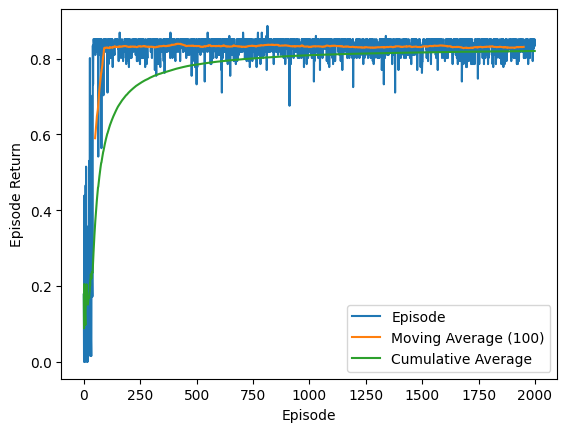

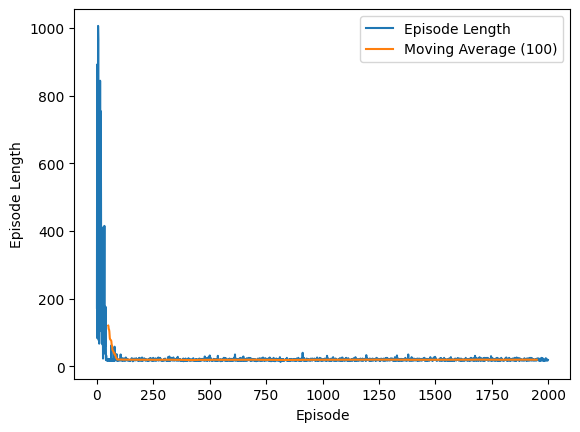

In [9]:
from gym_classics.algorithms.temporal_difference_learning import Q_learning

Q, history = Q_learning(env, n=2000, discount=.99, alpha = 0.01, epsilon = 0.1, history = True)

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

cum_average_returns["Q-learning"] = np.sum(history["returns"])/len(history["returns"])

## Approximation Methods

In [10]:
from gym_classics.algorithms.linear_approximation import transformation_fourier_basis

trans_fb = transformation_fourier_basis(min = np.array([0,0]), max = env.dims, order=2)

# overwrite state_features for the semi-gradient Sarsa implementation with Fourier basis features
def state_features(s, env):
    return trans_fb(env.id2state(s))

Semi-Gradient SARSA(0): 100%|██████████| 2000/2000 [00:11<00:00, 169.04it/s]


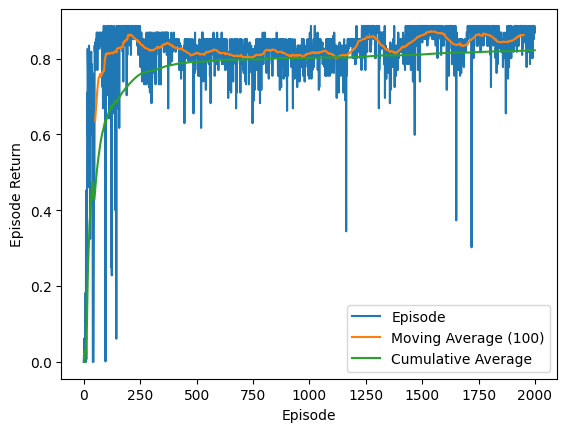

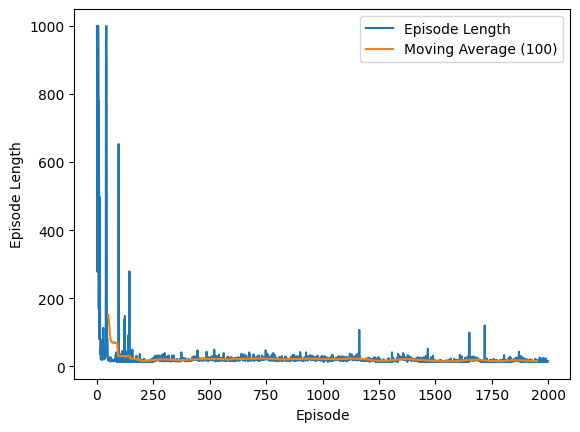

In [11]:
from gym_classics.algorithms.linear_approximation import semi_gradient_Sarsa_0
gym_classics.algorithms.linear_approximation.state_features = state_features

w, history = semi_gradient_Sarsa_0(env, n=2000, gamma=.99, alpha = 0.01, epsilon = 0.1, history = True)
plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

cum_average_returns["Semi-gradient Sarsa"] = np.sum(history["returns"])/len(history["returns"])

Semi-Gradient SARSA(lambda): 100%|██████████| 2000/2000 [00:24<00:00, 80.51it/s] 


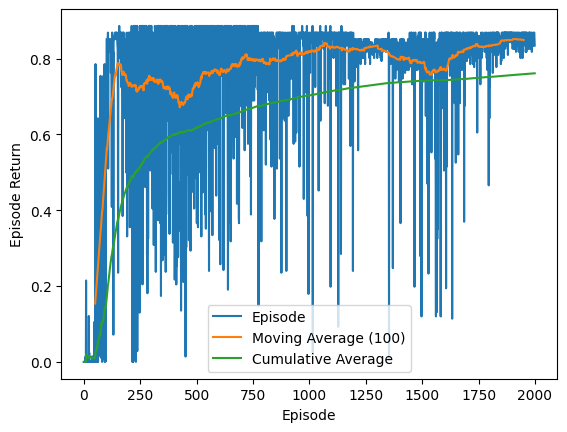

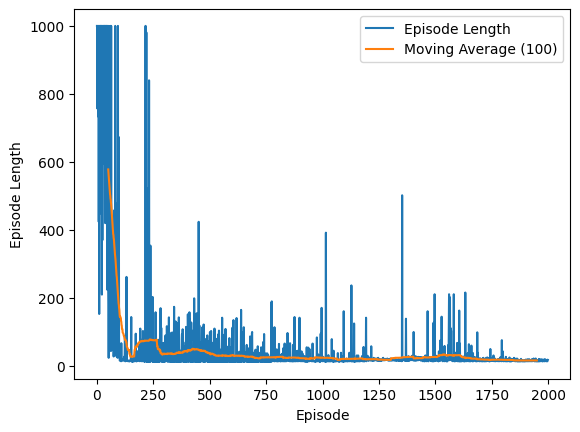

In [12]:
from gym_classics.algorithms.eligibility_traces import semi_gradient_Sarsa_lambda
gym_classics.algorithms.eligibility_traces.state_features = state_features

w, history = semi_gradient_Sarsa_lambda(env, n=2000, gamma=.99, lam = 0.5, alpha = 0.001, epsilon = 0.1, history = True, verbose = False)

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

cum_average_returns["Semi-gradient Sarsa(lambda)"] = np.sum(history["returns"])/len(history["returns"])

Episodes: 100%|██████████| 2000/2000 [02:19<00:00, 14.37it/s]


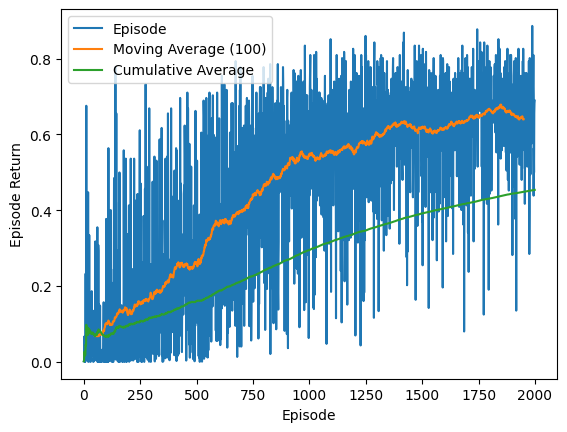

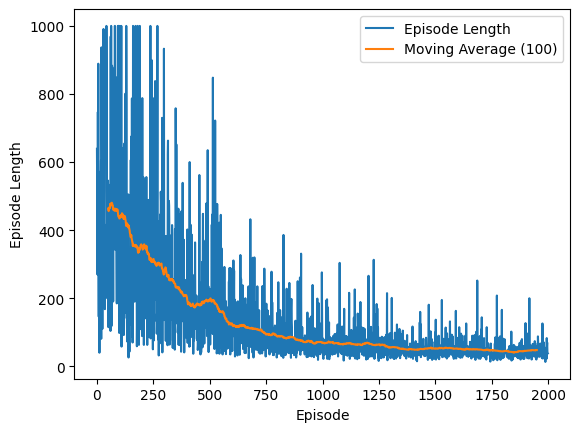

In [13]:
from gym_classics.algorithms.policy_gradient_methods import REINFORCE
gym_classics.algorithms.policy_gradient_methods.state_features = state_features

theta, history = REINFORCE(env, n= 2000, gamma=.99, alpha = .001, history = True, verbose = False)

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

cum_average_returns["REINFORCE alpha=.001"] = np.sum(history["returns"])/len(history["returns"])

REINFORCE seems to need a higher learning rate.

Episodes: 100%|██████████| 2000/2000 [00:55<00:00, 35.84it/s] 


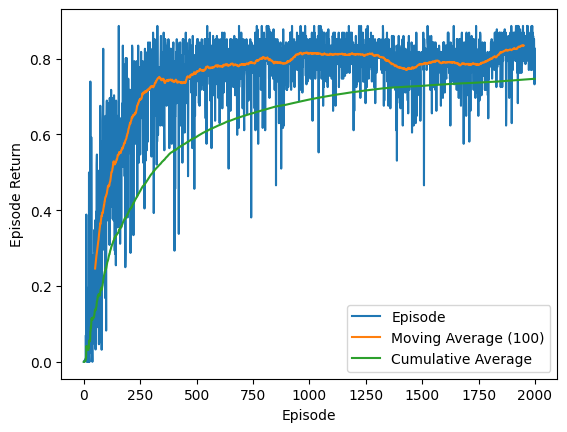

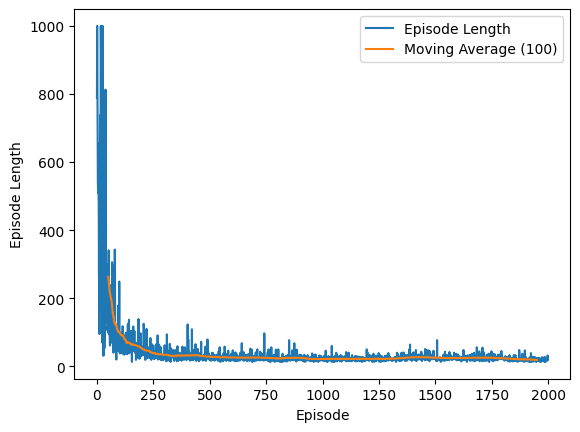

In [14]:
from gym_classics.algorithms.policy_gradient_methods import REINFORCE
gym_classics.algorithms.policy_gradient_methods.state_features = state_features

theta, history = REINFORCE(env, n= 2000, gamma=.99, alpha = .01, history = True, verbose = False)

plot_returns(history["returns"])
plot_ep_lens(history["ep_lens"])

cum_average_returns["REINFORCE alpha=.01"] = np.sum(history["returns"])/len(history["returns"])

## Compare the Average Return


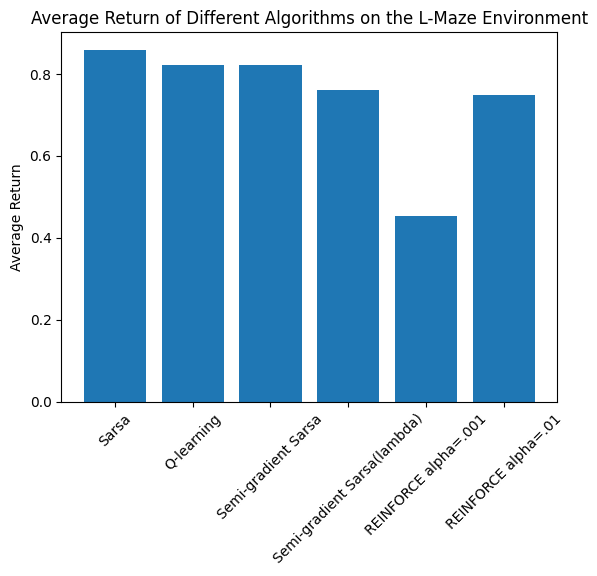

In [15]:
from matplotlib import pyplot as plt

plt.bar(cum_average_returns.keys(), cum_average_returns.values())
plt.ylabel("Average Return")
plt.title("Average Return of Different Algorithms on the L-Maze Environment")
plt.xticks(rotation=45)
plt.show()


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)